### 전복 나이테 회귀

202435119 한여원

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.keras
from tensorflow.keras import models, layers

In [58]:
df = pd.read_csv(r'D:\hanyeowon\Coding\pythonworks\deep\data\abalone.csv')
print(df)
print(df.dtypes)
print(df.columns)

        id Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
0        0   M   0.455     0.365   0.095        0.5140          0.2245   
1        1   M   0.350     0.265   0.090        0.2255          0.0995   
2        2   F   0.530     0.420   0.135        0.6770          0.2565   
3        3   M   0.440     0.365   0.125        0.5160          0.2155   
4        4   I   0.330     0.255   0.080        0.2050          0.0895   
...    ...  ..     ...       ...     ...           ...             ...   
4172  4172   F   0.565     0.450   0.165        0.8870          0.3700   
4173  4173   M   0.590     0.440   0.135        0.9660          0.4390   
4174  4174   M   0.600     0.475   0.205        1.1760          0.5255   
4175  4175   F   0.625     0.485   0.150        1.0945          0.5310   
4176  4176   M   0.710     0.555   0.195        1.9485          0.9455   

      Viscera_weight  Shell_weight  Rings  
0             0.1010        0.1500     15  
1             0.0485   

In [59]:
df = pd.get_dummies(df, columns=['Sex'])
df = df.drop('id', axis=1)
print(df)
X = df.drop('Rings', axis=1)
y = df['Rings']

      Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0      0.455     0.365   0.095        0.5140          0.2245          0.1010   
1      0.350     0.265   0.090        0.2255          0.0995          0.0485   
2      0.530     0.420   0.135        0.6770          0.2565          0.1415   
3      0.440     0.365   0.125        0.5160          0.2155          0.1140   
4      0.330     0.255   0.080        0.2050          0.0895          0.0395   
...      ...       ...     ...           ...             ...             ...   
4172   0.565     0.450   0.165        0.8870          0.3700          0.2390   
4173   0.590     0.440   0.135        0.9660          0.4390          0.2145   
4174   0.600     0.475   0.205        1.1760          0.5255          0.2875   
4175   0.625     0.485   0.150        1.0945          0.5310          0.2610   
4176   0.710     0.555   0.195        1.9485          0.9455          0.3765   

      Shell_weight  Rings  Sex_F  Sex_I

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [61]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # 모든 값들을 표준정규분포 형태로 변환
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1], )),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50


d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 34.8843 - mse: 34.8843 - val_loss: 9.5368 - val_mse: 9.5368
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10.9383 - mse: 10.9383 - val_loss: 6.5362 - val_mse: 6.5362
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0609 - mse: 8.0609 - val_loss: 5.8726 - val_mse: 5.8726
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.3059 - mse: 8.3059 - val_loss: 5.5218 - val_mse: 5.5218
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.3683 - mse: 7.3683 - val_loss: 5.4327 - val_mse: 5.4327
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0424 - mse: 7.0424 - val_loss: 5.4353 - val_mse: 5.4353
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7058 - mse: 6.7058 - val_loss: 5.2237 - val_mse: 5.2237
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2183 - mse: 6.2183 - val_loss: 5.2760 - val_mse: 5.2760
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


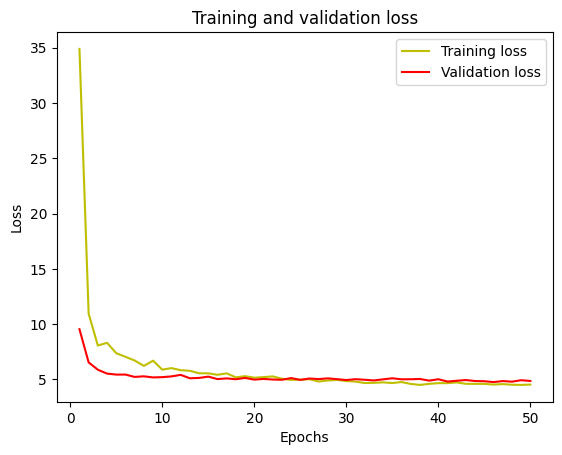

In [63]:
y_pred = model.predict(X_test_scaled)

loss = history.history['loss']
val_loss = history.history['val_loss']
mse = history.history['mse']
val_mse = history.history['val_mse']

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [64]:
print(loss)
print(val_loss)
print(mse)
print(val_mse)
print(y_test.shape)
print(y_pred.shape)
print(y_test)
print(y_pred)

[34.88425064086914, 10.938305854797363, 8.060912132263184, 8.305948257446289, 7.368258953094482, 7.042359828948975, 6.705812454223633, 6.218264579772949, 6.690317153930664, 5.880474090576172, 6.018229007720947, 5.830704689025879, 5.775678634643555, 5.55241584777832, 5.5466694831848145, 5.415078639984131, 5.544804096221924, 5.179156303405762, 5.292954921722412, 5.151381015777588, 5.203850269317627, 5.2687788009643555, 5.060825824737549, 4.95383358001709, 4.969083786010742, 5.012543201446533, 4.808753967285156, 4.89973783493042, 4.952821254730225, 4.84867000579834, 4.801153182983398, 4.67238187789917, 4.689926624298096, 4.728269100189209, 4.670388221740723, 4.758274078369141, 4.588418483734131, 4.498849391937256, 4.596088886260986, 4.659724712371826, 4.659126281738281, 4.725398063659668, 4.596851348876953, 4.594017505645752, 4.591372489929199, 4.5295867919921875, 4.5724592208862305, 4.516225814819336, 4.50031852722168, 4.529112339019775]
[9.536818504333496, 6.536174297332764, 5.872607707

In [65]:
from sklearn.metrics import r2_score
print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.5821897983551025
